In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import warnings
import torchvision.datasets as datasets
from torchvision import transforms
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print("GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 43
IMG_SIZE = 32
DATA_DIR = './data' 

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

train_dataset = datasets.GTSRB(root='./data', split='train', transform=transform, download=True)
test_dataset = datasets.GTSRB(root='./data', split='test', transform=transform, download=True)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

def dataset_to_numpy(dataset):
    X = []
    y = []
    for img, label in dataset:
        img_np = img.numpy().transpose(1, 2, 0)
        X.append(img_np)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Train: 26640, Test: 12630
X_train: (26640, 32, 32, 3), y_train: (26640,)
X_test: (12630, 32, 32, 3), y_test: (12630,)


In [4]:
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
def create_cnn_tf(input_shape=(32, 32, 3), num_classes=43):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Conv блок 1
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.1),
        
        # Conv блок 2
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),
        
        # Conv блок 3
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.3),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [11]:
print("\n--- Training TensorFlow CNN ---")
start_time = time.time()
model_tf = create_cnn_tf()
model_tf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_tf = model_tf.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1
)
print(f"Training time: {time.time() - start_time:.2f}s")


--- Training TensorFlow CNN ---
Epoch 1/10
417/417 [==============================] - 21s 49ms/step - loss: 2.8502 - accuracy: 0.1715 - val_loss: 1.8416 - val_accuracy: 0.3925
Epoch 2/10
417/417 [==============================] - 20s 47ms/step - loss: 1.4962 - accuracy: 0.4940 - val_loss: 1.2425 - val_accuracy: 0.5871
Epoch 3/10
417/417 [==============================] - 20s 47ms/step - loss: 0.7839 - accuracy: 0.7247 - val_loss: 0.5362 - val_accuracy: 0.8423
Epoch 4/10
417/417 [==============================] - 20s 48ms/step - loss: 0.2699 - accuracy: 0.9124 - val_loss: 0.3392 - val_accuracy: 0.9249
Epoch 5/10
417/417 [==============================] - 20s 48ms/step - loss: 0.1503 - accuracy: 0.9550 - val_loss: 0.2672 - val_accuracy: 0.9379
Epoch 6/10
417/417 [==============================] - 20s 48ms/step - loss: 0.0922 - accuracy: 0.9729 - val_loss: 0.2247 - val_accuracy: 0.9464
Epoch 7/10
417/417 [==============================] - 20s 48ms/step - loss: 0.0711 - accuracy: 0.9797 -

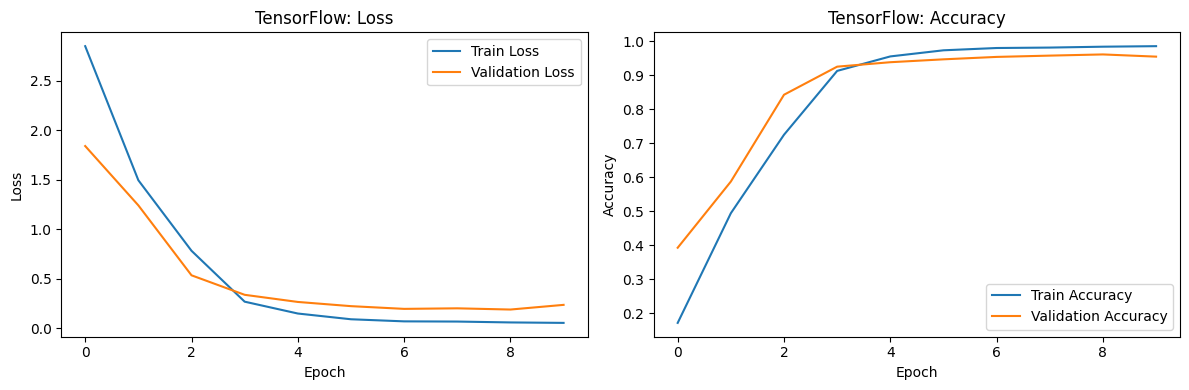

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_tf.history['loss'], label='Train Loss')
plt.plot(history_tf.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('TensorFlow: Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tf.history['accuracy'], label='Train Accuracy')
plt.plot(history_tf.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('TensorFlow: Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


--- Classification Report (TensorFlow CNN) ---
              precision    recall  f1-score   support

           0     0.9365    0.9833    0.9593        60
           1     0.9822    0.9958    0.9890       720
           2     0.9662    0.9907    0.9783       750
           3     0.9588    0.9822    0.9704       450
           4     0.9953    0.9727    0.9839       660
           5     0.9334    0.9349    0.9342       630
           6     0.9519    0.6600    0.7795       150
           7     0.9792    0.9422    0.9604       450
           8     0.9755    0.9733    0.9744       450
           9     0.9543    1.0000    0.9766       480
          10     0.9969    0.9848    0.9909       660
          11     0.9465    0.9690    0.9576       420
          12     0.9890    0.9101    0.9479       690
          13     0.9649    0.9917    0.9781       720
          14     1.0000    0.9481    0.9734       270
          15     0.8636    0.9952    0.9248       210
          16     0.9371    0.9933

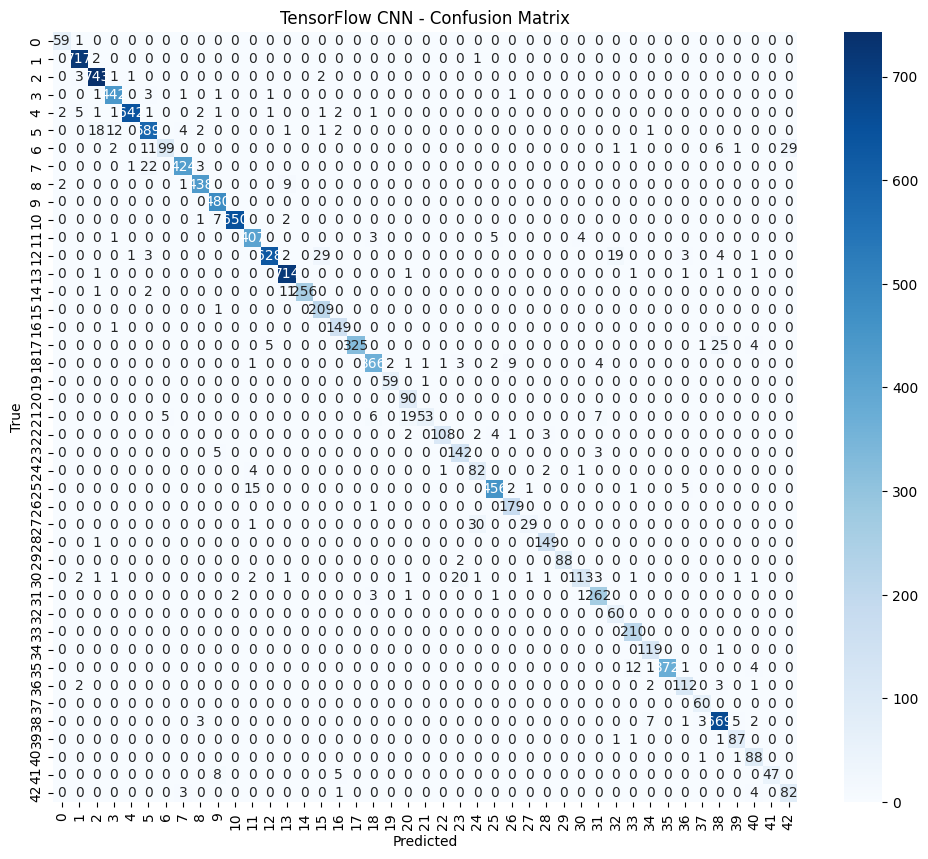

In [13]:
all_preds = []
all_labels = []

for images, labels in test_ds:
    preds = np.argmax(model_tf.predict(images, verbose=0), axis=1)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

print("\n--- Classification Report (TensorFlow CNN) ---")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('TensorFlow CNN - Confusion Matrix')
plt.show()

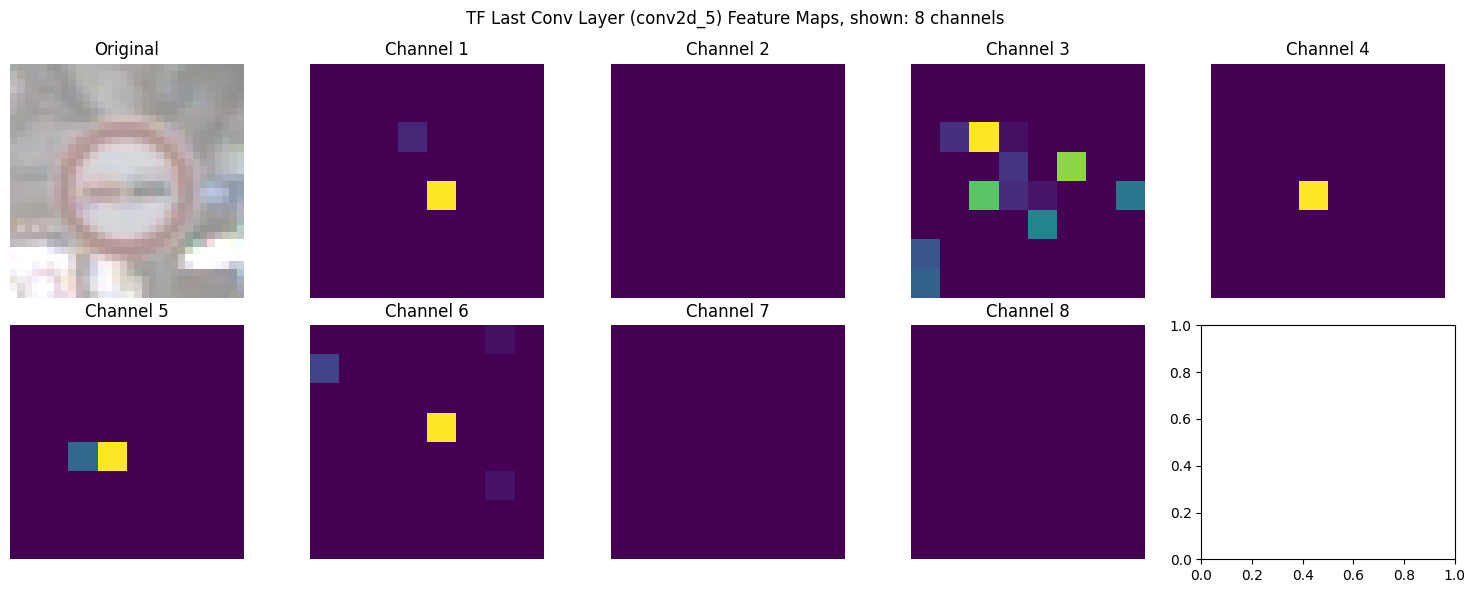

In [ ]:
def visualize_tf_last_feature_maps(model, image_tensor, num_maps=8):
    conv_layers = [layer.name for layer in model.layers if 'conv2d' in layer.name]
    last_conv = conv_layers[-1]
    feature_model = keras.Model(inputs=model.input, outputs=model.get_layer(last_conv).output)
    
    img_batch = tf.expand_dims(image_tensor, axis=0)
    features = feature_model(img_batch).numpy()[0]
    num_channels = features.shape[-1]
    n = min(num_maps, num_channels)
    
    img_display = (image_tensor.numpy() * 0.5) + 0.5
    fig, axes = plt.subplots(2, n//2 + 1, figsize=(15, 6))
    axes = axes.flatten()
    
    axes[0].imshow(img_display)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    for i in range(n):
        fm_channel = features[:, :, i]
        fm_channel = (fm_channel - fm_channel.min()) / (fm_channel.max() - fm_channel.min() + 1e-8)
        axes[i+1].imshow(fm_channel, cmap='viridis')
        axes[i+1].set_title(f'Channel {i+1}')
        axes[i+1].axis('off')
    
    plt.suptitle(f'TF Last Conv Layer ({last_conv}) Feature Maps, shown: {n} channels')
    plt.tight_layout()
    plt.show()

for batch in train_ds.take(1):
    images, labels = batch
    visualize_tf_last_feature_maps(model_tf, images[0], num_maps=8)
    break